In [1]:
#import libraries
import yfinance as yf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
#Portfolio construction

TICKERS = [
    # --- 1. US EQUITIES (Sector Diversification) ---
    "MSFT",   # Technology (Software & Cloud)
    "NVDA",   # Technology (Semiconductors)
    "LLY",    # Healthcare / Pharmaceuticals
    "JPM",    # Financials / Investment Banking
    "AMZN",   # Consumer Cyclical / E-Commerce
    "PG",     # Consumer Defensive / Consumer Goods
    "XOM",    # Energy / Oil & Gas
    "CAT",    # Industrials / Heavy Machinery
    "NEE",    # Utilities / Renewable Energy
    "AMT",    # Real Estate (REIT / Telecom Towers)

    # --- 2. INTERNATIONAL EQUITIES (Geographic Diversification) ---
    "ASML",   # Europe (Netherlands) - Semi-cap Equipment
    "NSRGY",  # Europe (Switzerland) - Consumer Goods (Nestlé)
    "SAP",    # Europe (Germany) - Enterprise Software
    "TM",     # Asia (Japan) - Automotive (Toyota)
    "SONY",   # Asia (Japan) - Electronics & Entertainment
    "TSM",    # Asia (Taiwan) - Semiconductor Foundry
    "BABA",   # Emerging Markets (China) - Tech & Retail
    "HDB",    # Emerging Markets (India) - Banking & Finance
    "VALE",   # Emerging Markets (Brazil) - Materials & Mining
    "RY",     # North America (Canada) - Banking (Royal Bank)

    # --- 3. FIXED INCOME (Bonds for De-correlation) ---
    "TLT",    # US Long-Term Treasury Bonds (20+ Years)
    "IEF",    # US Intermediate-Term Treasury Bonds (7-10 Years)
    "TIP",    # US Inflation-Protected Treasury Bonds (TIPS)
    "BNDX",   # Total International Bond ETF (Non-US Hedged)
    "EMB",    # Emerging Markets Sovereign Bond ETF

    # --- 4. ALTERNATIVE ASSETS & COMMODITIES (Alternative Allocation) ---
    "GLD",    # Gold Shares (Traditional Safe Haven)
    "SLV",    # Silver Shares (Precious & Industrial Metal)
    "USO",    # United States Oil Fund (WTI Crude Oil)
    "DBA",    # Invesco Agricultural Fund (Corn, Wheat, Soy, Coffee)
    "IBIT"    # iShares Bitcoin Trust (Spot Bitcoin ETF)
]



START = "2015-01-01"
END = "2025-01-01"
RF = 0.045  # Risk-free rate
PORTFOLIO_VALUE = 1_000_000  # Portfolio value
n = len(TICKERS)  # Number of tickers

#Data collection

df = yf.download(TICKERS, start=START, end=END, auto_adjust = True)['Close']
df.dropna(how='all', inplace=True)
df.ffill()  # forward-fill sporadic NaNs
df.dropna(inplace=True)

returns = df.pct_change().dropna()
print(f"{len(returns)} trading days of returns data collected for {n} assets from {START} to {END}.")

df.head()

[*********************100%***********************]  30 of 30 completed


244 trading days of returns data collected for 30 assets from 2015-01-01 to 2025-01-01.


Ticker,AMT,AMZN,ASML,BABA,BNDX,CAT,DBA,EMB,GLD,HDB,...,SAP,SLV,SONY,TIP,TLT,TM,TSM,USO,VALE,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-11,190.302521,155.179993,703.594116,69.028999,44.498440,281.975616,19.213295,77.450409,187.869995,31.917757,...,150.567841,20.820000,19.276686,98.495590,86.964195,186.341217,97.973984,67.650002,12.025746,90.811577
2024-01-12,191.933823,154.619995,698.394531,68.514000,44.498440,280.382538,19.111296,77.590668,189.710007,32.015400,...,152.520767,21.190001,19.760040,98.917740,86.793335,187.039001,97.993347,68.019997,11.936846,91.989632
2024-01-16,190.669098,153.160004,691.814148,66.244194,44.280926,277.312439,19.250387,76.871826,187.910004,29.867365,...,150.866074,20.959999,19.445068,98.413010,85.264641,186.962524,98.409561,67.250000,11.565083,89.909622
2024-01-17,187.828094,151.710007,697.464172,65.738724,44.154049,269.009308,19.111296,76.582542,185.839996,27.138391,...,151.789612,20.650000,19.296495,98.110168,85.129761,185.566986,99.648521,67.940002,11.363036,89.256172
2024-01-18,186.874969,153.500000,729.053650,64.899475,44.135929,272.166443,19.333843,76.661423,187.369995,27.592409,...,154.339005,20.809999,19.383657,98.137680,84.338409,191.244690,109.405258,69.059998,11.346872,89.090508


In [3]:
#Performance metrics
mean_returns = returns.mean()*252  # Annualized mean returns
volatility = returns.std()*np.sqrt(252)  # Annualized volatility
cov_matrix = returns.cov()*252  # Annualized covariance matrix

risk_df = pd.DataFrame({
    'Ann. Return' : mean_returns,
    'Ann. Volatility' : volatility,
    'Sharpe Ratio' : (mean_returns - RF) / volatility 
}).round(4)

print("Individual stock performance metrics:\n")
print(risk_df.to_string())

Individual stock performance metrics:

        Ann. Return  Ann. Volatility  Sharpe Ratio
Ticker                                            
AMT         -0.0627           0.2489       -0.4330
AMZN         0.3973           0.2815        1.2518
ASML         0.0753           0.4528        0.0669
BABA         0.2559           0.3773        0.5591
BNDX         0.0425           0.0376       -0.0668
CAT          0.2746           0.2621        0.8759
DBA          0.3144           0.1744        1.5444
EMB          0.0665           0.0713        0.3011
GLD          0.2737           0.1519        1.5053
HDB          0.0282           0.2834       -0.0591
IBIT         0.8750           0.5726        1.4495
IEF          0.0002           0.0674       -0.6648
JPM          0.3993           0.2381        1.4881
LLY          0.2531           0.3038        0.6851
MSFT         0.1224           0.2004        0.3862
NEE          0.2338           0.2549        0.7407
NSRGY       -0.2895           0.1966       

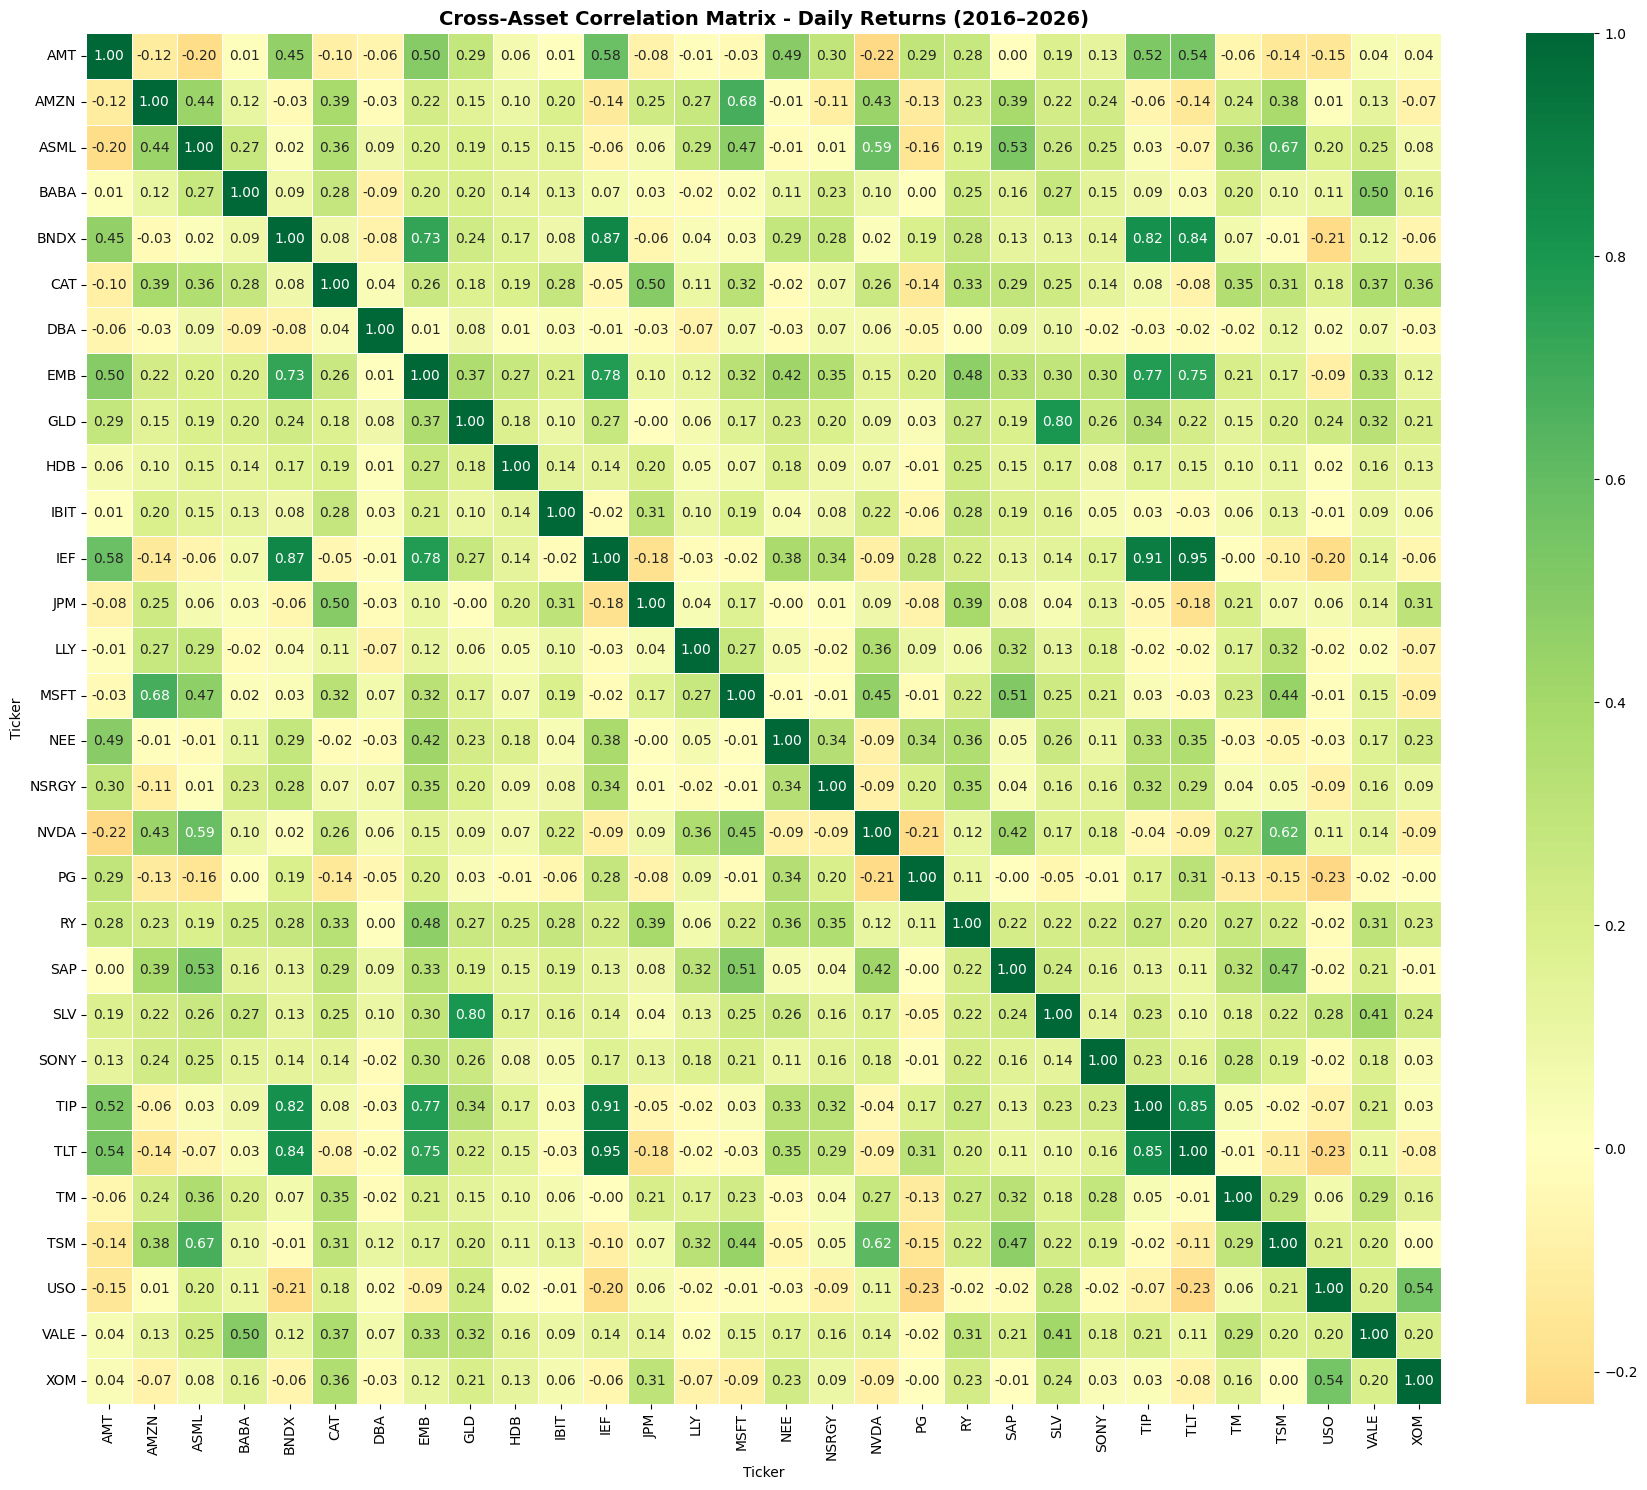

In [4]:
#Correlation heatmap
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(returns.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5)

ax.set_title('Cross-Asset Correlation Matrix - Daily Returns (2016–2026)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
#We create an equal weight portfolio

weights_eq = np.array([1/n]*n)  # Equal weights for each asset
port_ret_eq = np.sum(returns.mean() * 252 * weights_eq)
port_vol_eq = np.sqrt(np.dot(weights_eq.T, np.dot(cov_matrix, weights_eq)))
sharpe_eq = (port_ret_eq - RF) / port_vol_eq

print(f"Portfolio Performance Metrics:\n")

print("="*45)
print(f" {'':20}{'Equal Weight Portfolio':>20}")
print(f"{'Expected Return': <20} {port_ret_eq:10.2%}")   
print(f"{'Volatility': <20} {port_vol_eq:10.2%}")
print(f"{'Sharpe Ratio': <20} {sharpe_eq:.2f}")
print("="*45)

Portfolio Performance Metrics:

                     Equal Weight Portfolio
Expected Return          21.19%
Volatility               10.84%
Sharpe Ratio         1.54


In [6]:
#Portfolio Optimization using scipy

from scipy.optimize import minimize

#helper functions
def portfolio_return(weights):
    return np.sum(returns.mean() * 252 * weights)

def portfolio_volatility(weights):
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def neg_sharpe(weights):
    return -(portfolio_return(weights) - RF) / portfolio_volatility(weights)

#constraints and bounds
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0, 1) for _ in range(n))
init_guess = np.repeat(1/n, n)

#optimize for max Sharpe ratio
opt_sharpe = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

w_optimal = opt_sharpe.x
returns_optimal = portfolio_return(w_optimal)
volatility_optimal = portfolio_volatility(w_optimal)
sharpe_optimal = (returns_optimal - RF) / volatility_optimal

#optimize for minimum volatility
opt_min_vol = minimize(portfolio_volatility, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

w_min_volatility = opt_min_vol.x
returns_min_volatility = portfolio_return(w_min_volatility)
volatility_min_volatility = portfolio_volatility(w_min_volatility)
sharpe_min_volatility = (returns_min_volatility - RF) / volatility_min_volatility

print(f"Optimization complete using SLSQP.\n")
print(f"Max Sharpe Ratio Portfolio:")
print(f"  Expected Return: {returns_optimal:10.2%}")
print(f"  Volatility: {volatility_optimal:10.2%}")
print(f"  Sharpe Ratio: {sharpe_optimal:.2f}")


print(f"\nMinimum Volatility Portfolio:")
print(f"  Expected Return: {returns_min_volatility:10.2%}")
print(f"  Volatility: {volatility_min_volatility:10.2%}")   
print(f"  Sharpe Ratio: {sharpe_min_volatility:.2f}")

Optimization complete using SLSQP.

Max Sharpe Ratio Portfolio:
  Expected Return:     37.36%
  Volatility:      9.70%
  Sharpe Ratio: 3.39

Minimum Volatility Portfolio:
  Expected Return:      7.82%
  Volatility:      3.29%
  Sharpe Ratio: 1.01


In [7]:
# ----------------------------------------------- Daily portfolio returns  ---------------------------------------------------

#Max Sharpe Portfolio
port_returns = (returns * w_optimal).sum(axis=1)
var_results  = {}

print("  VALUE AT RISK & CVaR - Max Sharpe Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns, alpha * 100)
    cvar_pct = port_returns[port_returns <= var_pct].mean()
    var_results[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

#Minimum Volatility Portfolio
port_returns_min_vol = (returns * w_min_volatility).sum(axis=1) 
var_results_min_vol  = {}

print("  VALUE AT RISK & CVaR - Minimum Volatility Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns_min_vol, alpha * 100)
    cvar_pct = port_returns_min_vol[port_returns_min_vol <= var_pct].mean()
    var_results_min_vol[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

# Equal-Weight Portfolio
port_returns_eq = (returns * weights_eq).sum(axis=1)
var_results_eq = {}

print("  VALUE AT RISK & CVaR - Equal-Weight Portfolio")
print(f"    Portfolio value : €{PORTFOLIO_VALUE:,}\n")

for cl in [0.95, 0.99]:
    alpha    = 1 - cl
    var_pct  = np.percentile(port_returns_eq, alpha * 100)
    cvar_pct = port_returns_eq[port_returns_eq <= var_pct].mean()
    var_results_eq[cl] = {'var_pct': var_pct, 'cvar_pct': cvar_pct}

    print(f"   Confidence level : {cl:.0%}")
    print(f"   Historical VaR   : {var_pct:.2%}  (= €{var_pct * PORTFOLIO_VALUE:,.0f})")
    print(f"   Historical CVaR  : {cvar_pct:.2%}  (= €{cvar_pct * PORTFOLIO_VALUE:,.0f})")
    print()

  VALUE AT RISK & CVaR - Max Sharpe Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -0.96%  (= €-9,610)
   Historical CVaR  : -1.23%  (= €-12,267)

   Confidence level : 99%
   Historical VaR   : -1.40%  (= €-14,009)
   Historical CVaR  : -1.63%  (= €-16,254)

  VALUE AT RISK & CVaR - Minimum Volatility Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -0.36%  (= €-3,562)
   Historical CVaR  : -0.42%  (= €-4,160)

   Confidence level : 99%
   Historical VaR   : -0.45%  (= €-4,516)
   Historical CVaR  : -0.48%  (= €-4,824)

  VALUE AT RISK & CVaR - Equal-Weight Portfolio
    Portfolio value : €1,000,000

   Confidence level : 95%
   Historical VaR   : -1.25%  (= €-12,523)
   Historical CVaR  : -1.52%  (= €-15,154)

   Confidence level : 99%
   Historical VaR   : -1.61%  (= €-16,129)
   Historical CVaR  : -2.01%  (= €-20,063)



In [8]:
#summary of the results

In [9]:
# visualization of the cumulative returns of the Max Sharpe, Equal-Weight  and the SP500 portfolios 